In [1]:
import intake
import xarray as xr
import matplotlib.pyplot as plt
from dask_setup import setup_dask_client
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl

In [2]:
client, cluster, dask_tmp = setup_dask_client(
    mode="local", workload_type="io", reserve_mem_gb=2
)

INFO     [client] Starting Dask client setup (workload_type=io | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=4 | total_mem_gib=16.0)


INFO     [client] Temp/spill dir: /jobfs/171547141.gadi-pbs/dask-4149855
INFO     [client] Workers: 1 | threads/worker: 4 | processes: False
INFO     [client] Mem: total ~16.0 GiB | usable ~14.0 GiB | per-worker ~14.0 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/171547141.gadi-pbs/dask-4149855
Workers: 1 | threads/worker: 4 | processes: False
Memory: total ~16.0 GiB | usable ~14.0 GiB | per-worker ~14.0 GiB
Compression: spill=auto | comm=False


In [21]:
catalog = intake.open_esm_datastore("/g/data/ob53/catalog/v2/esm/catalog.json")
ua100m = catalog.search(
    source_id="BARRA-C2",
    variable_id="ua100m",
    freq="day",
    version="latest",
).to_dask()["ua100m"]
va100m = catalog.search(
    source_id="BARRA-C2",
    variable_id="va100m",
    freq="day",
    version="latest",
).to_dask()["va100m"]

In [22]:
REGION = {"lat": slice(-39, -29), "lon": slice(141, 151)}
TIMESPAN = {"time": slice(np.datetime64("2024-01-01"), None)}
sel = {**REGION, **TIMESPAN}
wspd = np.sqrt(ua100m.sel(sel) ** 2 + va100m.sel(sel) ** 2)

In [44]:
def coarsen(da, factor):
    return da.coarsen({"lon": factor, "lat": factor}, boundary="trim").mean()


CUT_IN_SPEED = 3.5
RATED_SPEED = 13.0
CUT_OUT_SPEED = 25.0


def capacity_factor(wspd):
    return xr.where(
        wspd < CUT_IN_SPEED,
        0.0,
        xr.where(
            wspd < RATED_SPEED,
            (wspd**3 - CUT_IN_SPEED**3) / (RATED_SPEED**3 - CUT_IN_SPEED**3),
            xr.where(wspd < CUT_OUT_SPEED, 1.0, 0.0),
        ),
    )


def is_drought(wspd, thresh, window):
    lt_thresh = capacity_factor(wspd) <= thresh
    all_window_lt_thresh = (
        (lt_thresh.rolling({"time": window}).sum("time") == window)  # fmt: skip
        .shift({"time": -(window - 1)}, fill_value=False)  # fmt: skip
    )
    any_all_window_lt_thresh = (
        all_window_lt_thresh.rolling({"time": window}, min_periods=1).sum("time") > 0
    )
    return any_all_window_lt_thresh


def probability_drought(wspd, thresh, window):
    return is_drought(wspd, thresh, window).mean("time")

In [36]:
def plot_diff(da1, da2):
    fig, axs = plt.subplots(
        1,
        3,
        figsize=(12, 4),
        sharex=True,
        sharey=True,
        layout="constrained",
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    meshes = []
    for ax, da in zip(axs, [da1, da2, da2 - da1]):
        meshes.append(
            ax.pcolormesh(da["lon"], da["lat"], da, transform=ccrs.PlateCarree())
        )
        ax.coastlines()

    meshes[1].set_clim(*meshes[0].get_clim())
    for m in meshes[:2]:
        m.set_cmap(mpl.colormaps["viridis"].resampled(8))
    cbars = [
        fig.colorbar(meshes[0], ax=axs[:2]),
        fig.colorbar(meshes[2], ax=axs[2]),
    ]

    clims = meshes[2].get_clim()
    new_clim = max(abs(clims[0]), abs(clims[1]))
    meshes[2].set_clim(-new_clim, new_clim)
    meshes[2].set_cmap(mpl.colormaps["RdBu_r"].resampled(7))

    axs[0].set_xlim(da1["lon"][0], da1["lon"][-1])
    axs[0].set_ylim(da1["lat"][0], da1["lat"][-1])

    return fig, axs, meshes, cbars

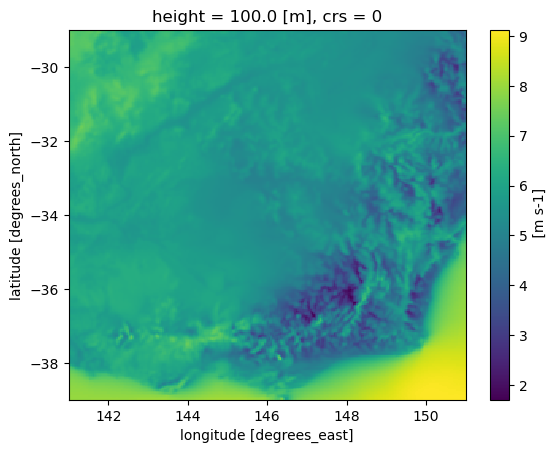

In [40]:
wspd.mean("time").plot()

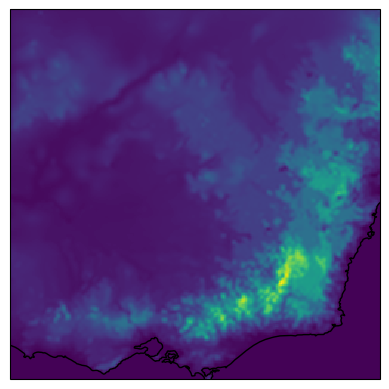

In [41]:
orog = (
    catalog.search(
        source_id="BARRA-C2",
        variable_id="orog",
        version="latest",
    )
    .to_dask()["orog"]
    .sel(REGION)
)
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.pcolormesh(orog["lon"], orog["lat"], orog)
ax.coastlines()

Text(0.5, 0.98, 'CF threshold = 0.0')

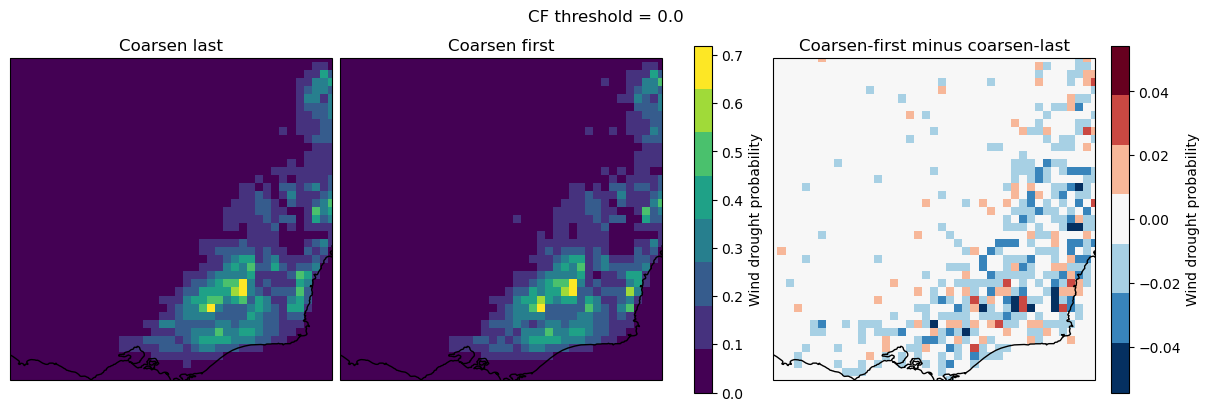

In [45]:
coarsen_last = coarsen(
    probability_drought(wspd, thresh=0.0, window=3), factor=6
).compute()
coarsen_first = probability_drought(
    coarsen(wspd, factor=6), thresh=0.0, window=3
).compute()

fig, axs, meshes, cbars = plot_diff(coarsen_last, coarsen_first)
axs[0].set_title("Coarsen last")
axs[1].set_title("Coarsen first")
axs[2].set_title("Coarsen-first minus coarsen-last")
for c in cbars:
    c.set_label("Wind drought probability")
fig.suptitle("CF threshold = 0.0")

Text(0.5, 0.98, 'CF threshold = 0.05')

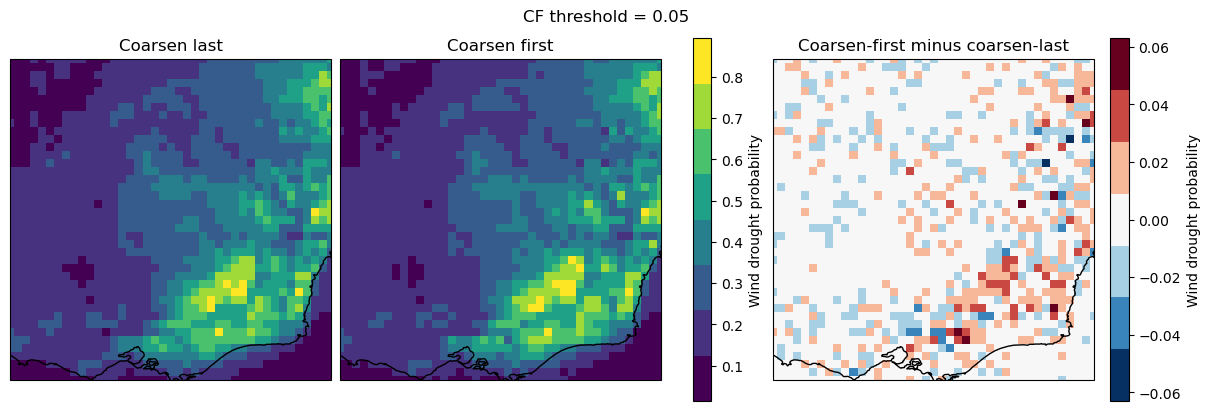

In [ ]:
coarsen_last = coarsen(
    probability_drought(wspd, thresh=0.05, window=3), factor=6
).compute()
coarsen_first = probability_drought(
    coarsen(wspd, factor=6), thresh=0.05, window=3
).compute()

fig, axs, meshes, cbars = plot_diff(coarsen_last, coarsen_first)
axs[0].set_title("Coarsen last")
axs[1].set_title("Coarsen first")
axs[2].set_title("Coarsen-first minus coarsen-last")
for c in cbars:
    c.set_label("Wind drought probability")
fig.suptitle("CF threshold = 0.05")

Text(0.5, 0.98, 'CF threshold = 0.1')

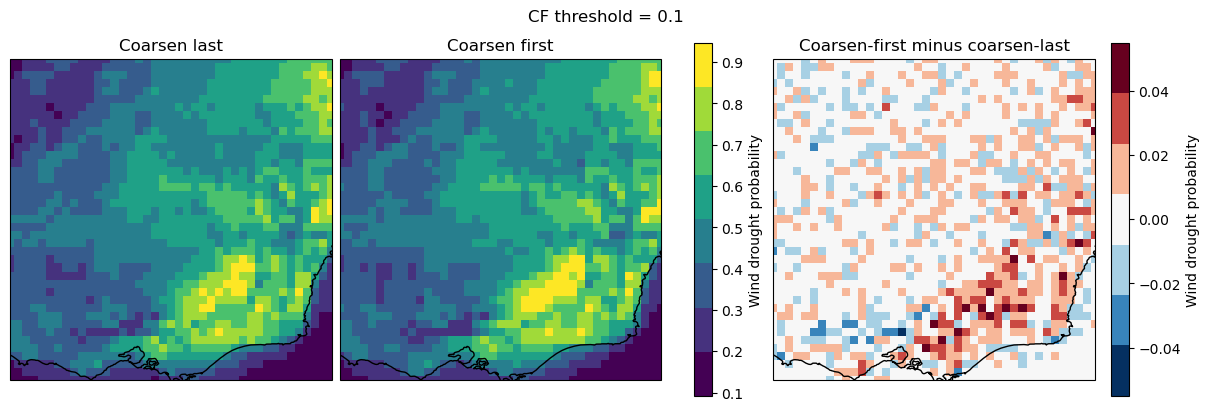

In [37]:
coarsen_last = coarsen(
    probability_drought(wspd, thresh=0.1, window=3), factor=6
).compute()
coarsen_first = probability_drought(
    coarsen(wspd, factor=6), thresh=0.1, window=3
).compute()

fig, axs, meshes, cbars = plot_diff(coarsen_last, coarsen_first)
axs[0].set_title("Coarsen last")
axs[1].set_title("Coarsen first")
axs[2].set_title("Coarsen-first minus coarsen-last")
for c in cbars:
    c.set_label("Wind drought probability")
fig.suptitle("CF threshold = 0.1")

Text(0.5, 0.98, 'CF threshold = 0.2')

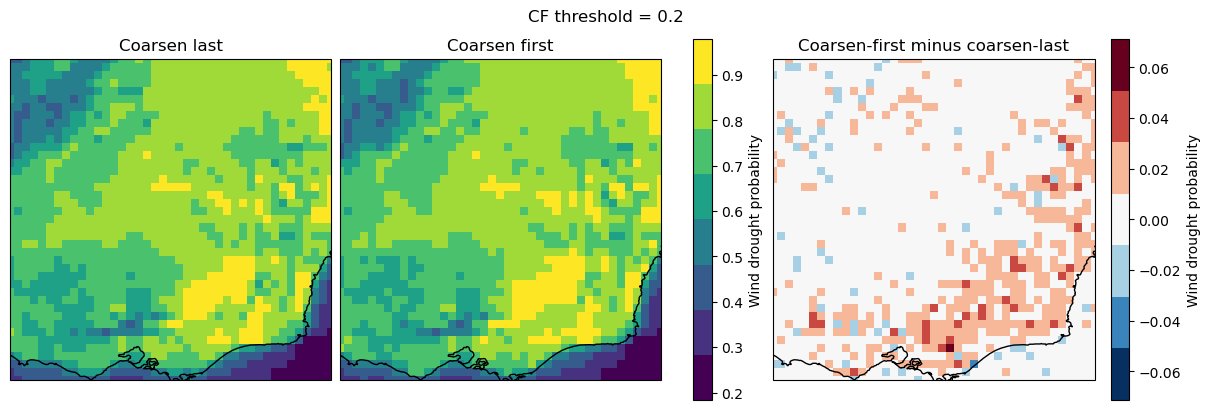

In [43]:
coarsen_last = coarsen(
    probability_drought(wspd, thresh=0.2, window=3), factor=6
).compute()
coarsen_first = probability_drought(
    coarsen(wspd, factor=6), thresh=0.2, window=3
).compute()

fig, axs, meshes, cbars = plot_diff(coarsen_last, coarsen_first)
axs[0].set_title("Coarsen last")
axs[1].set_title("Coarsen first")
axs[2].set_title("Coarsen-first minus coarsen-last")
for c in cbars:
    c.set_label("Wind drought probability")
fig.suptitle("CF threshold = 0.2")